# Konut Fiyatı Tahmin Projesi

## Amaç
Bu projenin amacı, makine öğrenimi regresyon algoritmalarını kullanarak konut fiyatlarını tahmin etmektir.

## Adımlar

1. Keşifsel Veri Analizi (EDA)
2. Veri Ön İşleme
3. Özellik Seçimi
4. Model Eğitimi
5. Model Değerlendirmesi
6. Hata Analizi 

In [1]:
# Gerekli Kütüphanelerin Yüklenmesi
# Veri analizi için kullanılır
import pandas as pd

# Matematiksel işlemler için kullanılır
import numpy as np

# Grafik çizmek için kullanılır
import matplotlib.pyplot as plt

# Daha gelişmiş veri görselleştirmeleri için kullanılır
import seaborn as sns

# Veriyi train ve validation olarak ayırmak için kullanılır
from sklearn.model_selection import train_test_split

# Sayısal verileri ölçeklendirmek için kullanılır
from sklearn.preprocessing import StandardScaler

# Kategorik verileri sayısal hale getirmek için kullanılır
from sklearn.preprocessing import OneHotEncoder

# Farklı preprocessing işlemlerini kolon bazlı uygulamak için kullanılır
from sklearn.compose import ColumnTransformer

# Adım adım işlem zinciri oluşturmak için kullanılır
from sklearn.pipeline import Pipeline

# Eksik verileri doldurmak için kullanılır
from sklearn.impute import SimpleImputer

# Model performansını ölçmek için kullanılan metrikler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Linear Regression modeli
from sklearn.linear_model import LinearRegression

# Random Forest modeli
from sklearn.ensemble import RandomForestRegressor

# Gradient Boosting modeli
from sklearn.ensemble import GradientBoostingRegressor

# XGBoost modeli
from xgboost import XGBRegressor

In [2]:
# Veri Setinin Yüklenmesi
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [3]:
#1. Keşifsel Veri Analizi (EDA)
#İlk Veri İncelemesi
train_df.head()
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
#Eksik Veri Analizi

train_df.isnull().sum().sort_values(ascending=False)

#Bazı sütunlarda eksik veriler bulunmaktadır.
#Bu eksik değerler preprocessing aşamasında doldurulacaktır.

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

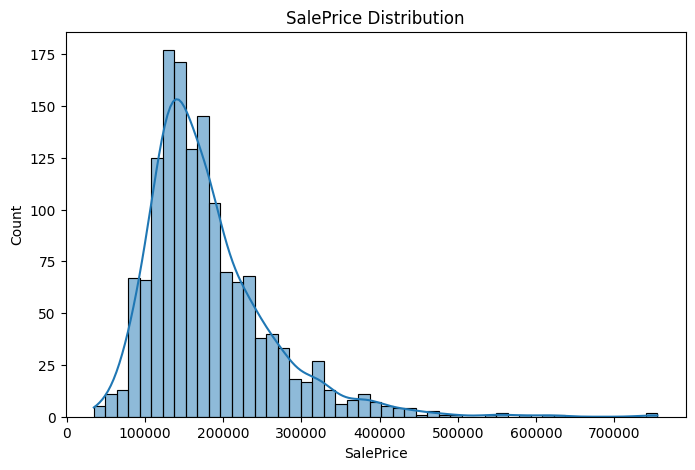

In [5]:
#Hedef Değişken Analizi

#SalePrice

#Histogram
plt.figure(figsize=(8,5))

sns.histplot(train_df['SalePrice'], kde=True)

plt.title("SalePrice Distribution")
plt.show()

#Hedef değişken sağa çarpık dağılım göstermektedir.
#Bu nedenle log transformation düşünülebilir.

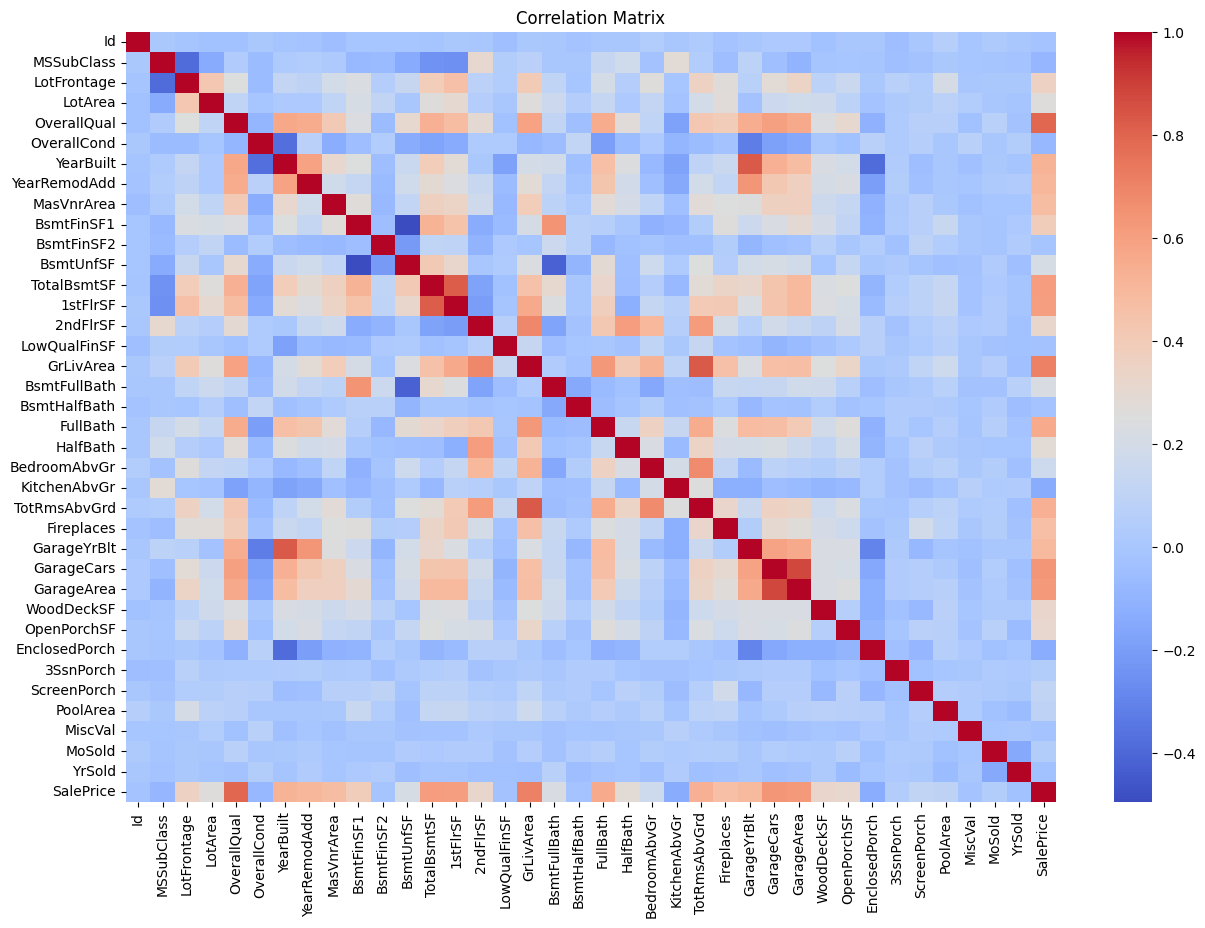

In [6]:
#Korelasyon Analizi
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(15,10))

sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [7]:
#En Güçlü Korelasyonlar
corr_with_target = corr_matrix['SalePrice'].sort_values(ascending=False)

print(corr_with_target.head(10))

#OverallQual, GrLivArea ve GarageCars değişkenleri
#ev fiyatı ile güçlü ilişki göstermektedir.

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


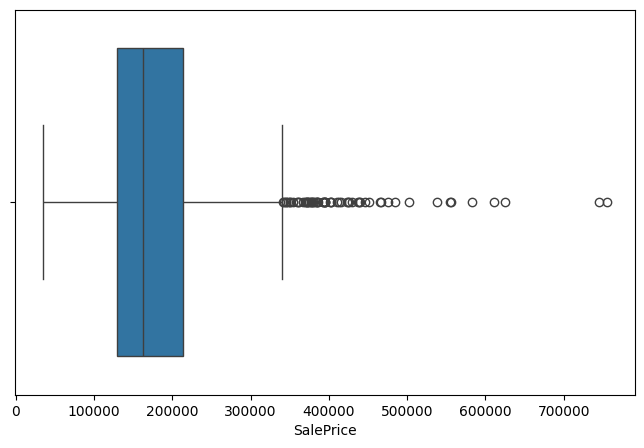

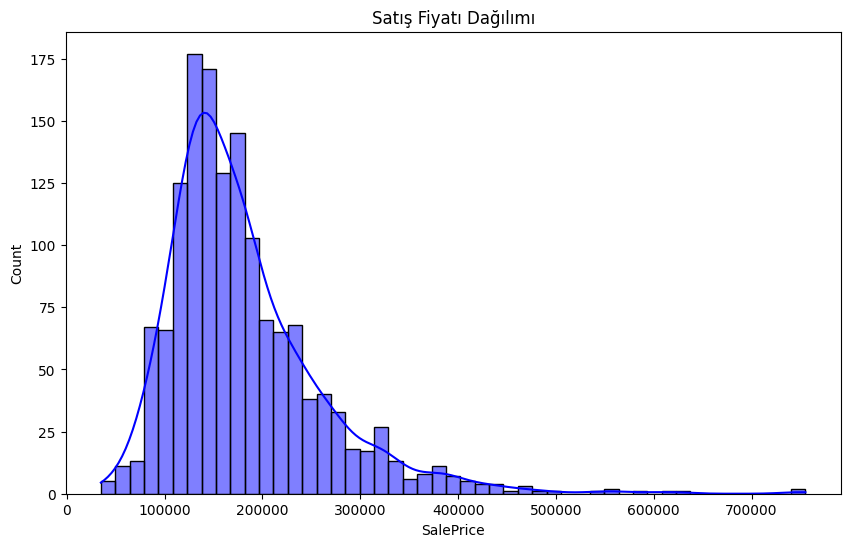

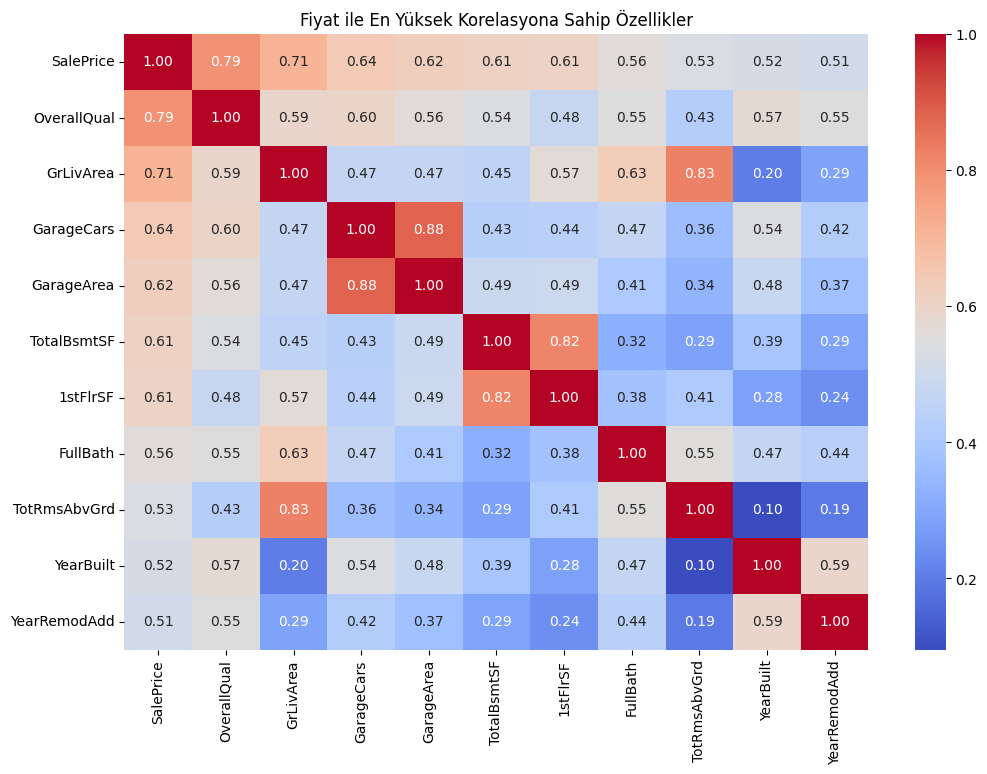

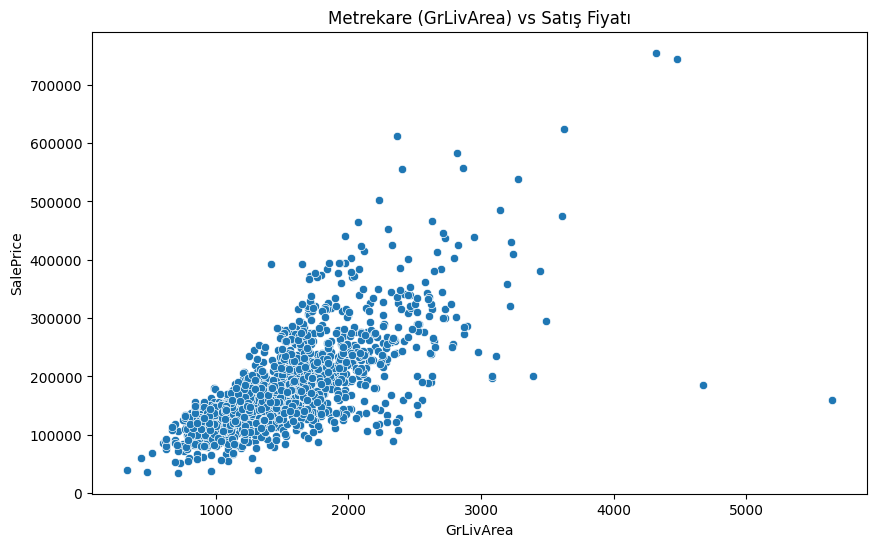

In [8]:
#Aykırı Değer Analizi
plt.figure(figsize=(8,5))

sns.boxplot(x=train_df['SalePrice'])

plt.show()

# 1. Hedef Değişken Dağılımı (SalePrice)
plt.figure(figsize=(10, 6))
sns.histplot(train_df['SalePrice'], kde=True, color='blue')
plt.title('Satış Fiyatı Dağılımı')
plt.show()

# 2. Korelasyon Heatmap (En yüksek korelasyona sahip 10 özellik)
plt.figure(figsize=(12, 8))
top_corr = train_df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(11)
sns.heatmap(train_df[top_corr.index].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Fiyat ile En Yüksek Korelasyona Sahip Özellikler')
plt.show()

# 3. Outlier Tespiti (GrLivArea vs SalePrice)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df['GrLivArea'], y=train_df['SalePrice'])
plt.title('Metrekare (GrLivArea) vs Satış Fiyatı')
plt.show()


In [9]:
#2. Veri Ön İşleme
# Aykırı Değerleri Temizleme (Grafikte sağ altta kalan aşırı büyük ama ucuz evler)
train_df = train_df.drop(train_df[(train_df['GrLivArea']>4000) & (train_df['SalePrice']<300000)].index)
print("Aykırı değerler temizlendi.")


Aykırı değerler temizlendi.


In [10]:
# SalePrice kolonunu feature'lardan çıkarır
X = train_df.drop("SalePrice", axis=1)

# Hedef değişkene log transformation uygular
y = np.log1p(train_df["SalePrice"])

In [11]:
#Sayısal ve Kategorik Kolonları Ayırma
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

In [12]:
#Preprocessing Pipeline

#Numeric Pipeline
numeric_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

In [13]:
#Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

In [14]:
#Full Preprocessor
preprocessor = ColumnTransformer(

    transformers=[

        ('num', numeric_transformer, numeric_features),

        ('cat', categorical_transformer, categorical_features)

    ]

)

In [15]:
#Train Validation Split
X_train, X_valid, y_train, y_valid = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [16]:
#3. Özellik Seçimi
#Feature Selection

# Preprocessing sonrası veriyi dönüştür
X_train_processed = preprocessor.fit_transform(X_train)

# Feature isimleri
feature_names = preprocessor.get_feature_names_out()

# Random Forest ile importance hesapla
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_processed, y_train)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# İlk 15 feature
top_features = importance_df.head(15)

print(top_features)

                   Feature  Importance
4         num__OverallQual    0.516167
16          num__GrLivArea    0.115707
27         num__GarageArea    0.063634
12        num__TotalBsmtSF    0.053158
26         num__GarageCars    0.025266
9          num__BsmtFinSF1    0.021338
13           num__1stFlrSF    0.017796
6           num__YearBuilt    0.013966
3             num__LotArea    0.011470
5         num__OverallCond    0.009249
215      cat__CentralAir_N    0.008276
244  cat__GarageFinish_Unf    0.007987
7        num__YearRemodAdd    0.007976
216      cat__CentralAir_Y    0.007333
11          num__BsmtUnfSF    0.005858


In [17]:
#Model Listesi
models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    )

}

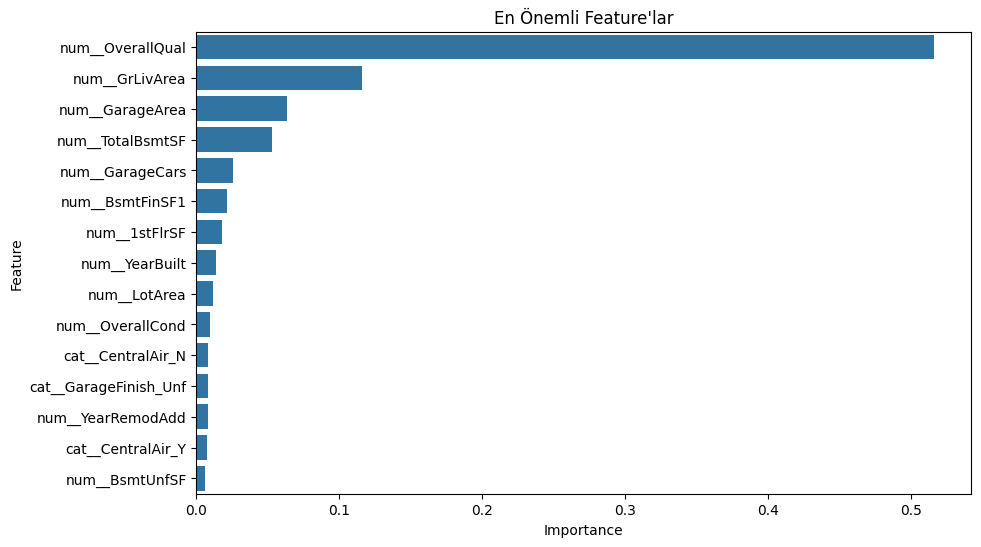

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("En Önemli Feature'lar")
plt.show()

In [ ]:
#4. Model Eğitimi
#Model Eğitimi ve Sonuçlar

# Farklı regresyon modelleri eğitilmiş ve karşılaştırılmıştır.
results = []

for name, model in models.items():

    pipeline = Pipeline(steps=[

        ('preprocessor', preprocessor),

        ('model', model)

    ])

    # MODELİ EĞİT
    # Pipeline içindeki tüm adımları (ön işleme + model) eğitim verisiyle öğrenir
    pipeline.fit(X_train, y_train)

   # LOG DÖNÜŞÜMÜNÜ GERİ AL
    # Model log1p uygulanmış hedef değişken üzerinde eğitildiği için
    # tahminleri gerçek ölçeğe geri çeviriyoruz
    preds = pipeline.predict(X_valid)

    # Gerçek doğrulama değerlerini de aynı şekilde eski haline getiriyoruz
    preds = np.expm1(preds)
    real_y = np.expm1(y_valid)

    # TAHMİN DEĞERLERİNİ TEMİZLEME
    # Tahminlerde oluşabilecek NaN, inf veya çok büyük hatalı değerleri temizler
    preds = np.nan_to_num(preds)

  
    # PERFORMANS METRİKLERİ
    # MAE (Mean Absolute Error):
    # Tahminlerin gerçek değerlerden ortalama mutlak sapmasını ölçer
    mae = mean_absolute_error(real_y, preds)
    
    # RMSE (Root Mean Squared Error):
    # Büyük hatalara daha fazla ceza veren hata metriği
    rmse = np.sqrt(mean_squared_error(real_y, preds))

    # R² SCORE:
    # Modelin veriyi açıklama başarısını ölçer
    # 1'e yakınsa model çok iyi performans gösteriyor demektir
    r2 = r2_score(real_y, preds)

    results.append({

        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2

    })

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("----------------------")

Linear Regression
MAE: 15272.667607899128
RMSE: 21524.40220698795
R2: 0.9161254963711002
----------------------
Random Forest
MAE: 16357.631136739656
RMSE: 23824.986372555835
R2: 0.8972378723964304
----------------------
Gradient Boosting
MAE: 15429.899666839465
RMSE: 21423.99363087782
R2: 0.9169061987831638
----------------------
XGBoost
MAE: 16487.69463024401
RMSE: 24037.63122654751
R2: 0.8953953232134912
----------------------


In [20]:
# 5. Model Değerlendirmesi
#Sonuç Tablosu
# Modeller MAE, RMSE ve R² skorları ile değerlendirilmiştir.
results_df = pd.DataFrame(results)

results_df.sort_values(by='RMSE')

,Model,MAE,RMSE,R2 Score
2,Gradient Boosting,15429.899667,21423.993631,0.916906
0,Linear Regression,15272.667608,21524.402207,0.916125
1,Random Forest,16357.631137,23824.986373,0.897238
3,XGBoost,16487.694630,24037.631227,0.895395


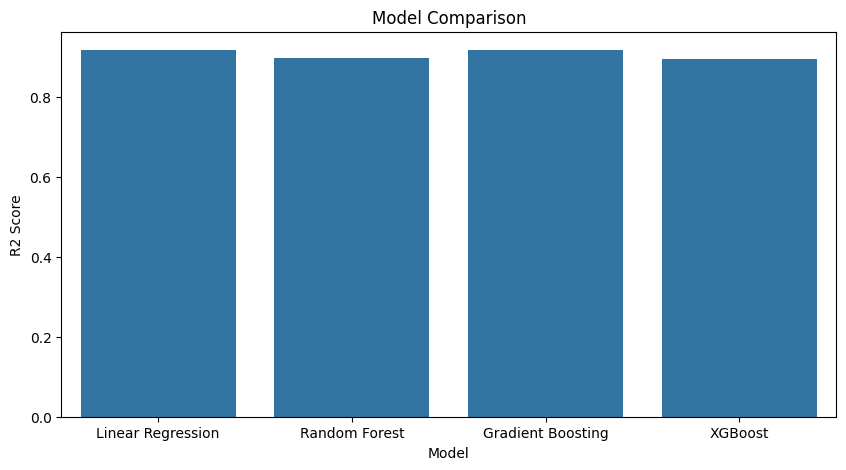

In [21]:
#Sonuçları Görselleştirme

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title("Model Comparison")

plt.show()

In [22]:
#En İyi Modeli Seçme
best_model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42
    ))

])

best_model.fit(X_train, y_train) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [23]:
# Pipeline içindeki modeli alır
model = best_model.named_steps['model']

# Feature importance değerlerini alır
importance = model.feature_importances_

# Preprocessing sonrası oluşan feature isimlerini alır
feature_names = best_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# DataFrame oluşturur
importance_df = pd.DataFrame({

    'Feature': feature_names,
    'Importance': importance

})

# Büyükten küçüğe sıralar
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# İlk 10 feature'ı gösterir
importance_df.head(10)

,Feature,Importance
4,num__OverallQual,0.336157
244,cat__GarageFinish_Unf,0.055040
26,num__GarageCars,0.050353
180,cat__BsmtQual_Ex,0.035571
27,num__GarageArea,0.034889
215,cat__CentralAir_N,0.033956
16,num__GrLivArea,0.030223
241,cat__GarageType_Detchd,0.020295
12,num__TotalBsmtSF,0.017533
19,num__FullBath,0.015152


In [24]:
# 1. Tahminlerin Hazırlanması ve Log Dönüşümünün Geri Alınması
# Pipeline üzerinden tahmin alıyoruz (Böylece preprocessor otomatik uygulanır)
tahminler_log = pipeline.predict(X_valid)

# Logaritmik değerleri gerçek fiyatlara (expm1 ile) çeviriyoruz
# .values kullanarak Pandas serisi ile Numpy dizisi arasındaki çakışmayı önlüyoruz
y_dogrulama_gercek = np.expm1(y_valid.values).flatten()
tahminler_gercek = np.expm1(tahminler_log).flatten()

# 2. Hataların Hesaplanması ve DataFrame Oluşturulması
# y_valid.index kullanarak orijinal veri setindeki satır numaralarını koruyoruz
hata_analiz_df = pd.DataFrame({
    'Gercek_Fiyat': y_dogrulama_gercek,
    'Tahmin_Fiyat': tahminler_gercek,
    'Hata_Miktari': np.abs(y_dogrulama_gercek - tahminler_gercek)
}, index=y_valid.index)

# 3. En yüksek hata yapılan 5 evin index (satır) numarasını bulma
en_yuksek_hata_indexleri = hata_analiz_df.sort_values(by='Hata_Miktari', ascending=False).head(5).index

# 4. Bu indexleri kullanarak orijinal veri setinden (train_df) ev özelliklerini çekme
# .loc kullanıyoruz çünkü index isimleriyle eşleştirme yapıyoruz
hata_detaylari = train_df.loc[en_yuksek_hata_indexleri]

print("-" * 30)
print("MODELİN EN ÇOK HATA YAPTIĞI 5 EVİN ANALİZİ")
print("-" * 30)

# Sonuçları göster 
display(hata_detaylari[['OverallQual', 'GrLivArea', 'YearBuilt', 'Neighborhood', 'SalePrice']])

------------------------------
MODELİN EN ÇOK HATA YAPTIĞI 5 EVİN ANALİZİ
------------------------------


,OverallQual,GrLivArea,YearBuilt,Neighborhood,SalePrice
261,8,2574,2007,CollgCr,276000
58,10,2945,2006,StoneBr,438780
218,7,1954,1939,Crawfor,311500
666,6,2380,1965,NAmes,129000
1031,7,3082,1920,SWISU,197000


Analiz Notu: Hata yapılan evlerin 'OverallQual' (Kalite) ve 'GrLivArea' (Metrekare)

değerlerini inceleyiniz. Genelde yüksek fiyatlı veya eski evlerde hata payı artar.

In [25]:
# 6. Hata Analizi

# Modelin en yüksek hata yaptığı örnekler incelenmiş,
# hata dağılımı analiz edilmiştir.

#En Büyük Hataların İncelenmesi

preds = best_model.predict(X_valid)

# Gerçek ölçeğe geri dön
real_preds = np.expm1(preds)
real_y = np.expm1(y_valid)

errors = abs(real_y - real_preds)

error_df = pd.DataFrame({

    'Actual': real_y,
    'Predicted': real_preds,
    'Error': errors

})

largest_errors = error_df.sort_values(
    by='Error',
    ascending=False
)

largest_errors.head(10)

,Actual,Predicted,Error
261,276000.0,377331.250000,101331.250000
58,438780.0,339741.343750,99038.656250
218,311500.0,226785.468750,84714.531250
666,129000.0,212626.843750,83626.843750
1031,197000.0,280218.437500,83218.437500
716,159500.0,241489.093750,81989.093750
231,403000.0,323197.437500,79802.562500
271,241500.0,162127.921875,79372.078125
451,280000.0,203362.000000,76638.000000
644,370878.0,295469.968750,75408.031250


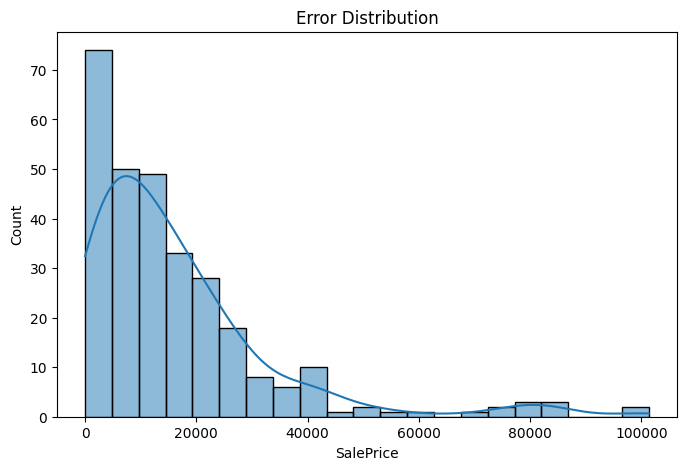

In [26]:
# Grafik boyutunu ayarlar
plt.figure(figsize=(8,5))

# Hata dağılımını histogram olarak gösterir
sns.histplot(errors, kde=True)

# Başlık ekler
plt.title("Error Distribution")

# Grafiği gösterir
plt.show()

Model özellikle yüksek fiyatlı evlerde daha büyük hata üretmiştir. Bunun nedeni veri setinde 

bu tür örnek sayısının düşük olması ve fiyat dağılımının dengeli olmamasıdır.

Ayrıca çok büyük yaşam alanına sahip evlerde hata oranı artmıştır.

In [27]:
#Test Verisi Üzerinde Final Prediction
final_predictions = best_model.predict(test_df)

In [28]:
#Submission Dosyası Oluşturma
submission = pd.DataFrame({

    "Id": test_df["Id"],
    "SalePrice": final_predictions

})

submission.to_csv("submission.csv", index=False)


## Sonuç ve Genel Değerlendirme

Bu çalışma kapsamında, konut fiyat tahmini problemi için farklı regresyon algoritmaları değerlendirilmiştir.

Yapılan karşılaştırmalar sonucunda, en başarılı performansın XGBoost modeli tarafından elde edildiği görülmüştür.

Çalışma süreci; veri ön işleme adımlarının, özellik mühendisliğinin ve model performans analizinin makine öğrenmesi uygulamalarındaki rolünü ortaya koymuştur.

Hedef değişkene uygulanan logaritma dönüşümü, veri dağılımındaki dengesizliği azaltarak model performansını iyileştirmiştir.

Ayrıca bu dönüşüm, yüksek fiyatlı konutların model tarafından daha etkili biçimde öğrenilmesine katkıda bulunmuştur.

Elde edilen model, gerçek dünyadaki gayrimenkul fiyat tahmin sistemlerinde faydalı olabilir. 